In [1073]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage.filters import gaussian_filter1d
import itertools
import math
import copy
import ptitprince as pt



species_color = {'Marmoset': "orange",
 'Human': "green",
 'Rhesus': "blue",
 'Chimpanzee': "red",
 'Capuchin': "brown",
 "Gorilla": "pink"}

PYTHON_PATH = "/Users/rb4174/Documents/projects/brain_dev_primates/altricial_brain_vocal_learning"
PYTHON_PATH = "/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/altricial_brain_vocal_learning"


def condition(column,low_percentil,high_percentil):
    result_min = all(a >= b for a, b in zip(column, low_percentil))
    result_max = all(a <= b for a, b in zip(column, high_percentil))

    if result_min and result_max:
        return True
    else:
        return False


adult_sizes_df = pd.read_excel("/Users/rb4174/Library/CloudStorage/OneDrive-PrincetonUniversity/Projects/brain_dev_primates/data/adult_primates_brain_volumes.xlsx",
                               sheet_name="from_ref") # "from_ref", from_my_data
adult_sizes_df = adult_sizes_df.replace("chimpanzee", "Chimpanzee")
adult_sizes_df = adult_sizes_df.replace("human", "Human")
adult_sizes_df = adult_sizes_df.replace("marmoset", "Marmoset")
adult_sizes_df = adult_sizes_df.replace("rhesus", "Rhesus")
adult_sizes_df = adult_sizes_df.replace("capuchin", "Capuchin")
adult_sizes_df = adult_sizes_df.replace("gorilla", "Gorilla")

adult_size = {}
for specie in adult_sizes_df["species"].unique():
    adult_size[specie] = np.mean(adult_sizes_df[(adult_sizes_df.species == specie)]["total_cm3"])


DIVISION_DAYS = 30.5
X_LABEL = "Months post conception"

/var/folders/ys/4vmt6skn47v69q7dptm_7p3m0000gp/T/ipykernel_23228/878125402.py:5: DeprecationWarning: Please use `gaussian_filter1d` from the `scipy.ndimage` namespace, the `scipy.ndimage.filters` namespace is deprecated.
  from scipy.ndimage.filters import gaussian_filter1d


In [1074]:
df_fit = pd.read_pickle("{0}/data/derivatives_absolute_values.pkl".format(PYTHON_PATH)) 
df_events = pd.read_excel("{0}/data/developmental_stages_events.xlsx".format(PYTHON_PATH),index_col=False)
species_list = ["Human","Marmoset","Chimpanzee","Rhesus"]#,"Capuchin","Gorilla"]

In [1075]:
df_fit.head()

,species,x_dydx,derivatives,derivatives_max,derivatives_peak_at_birth
0,Human,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[3.064614918457664e-05, 0.0001225853041546543...","[2.4194334486632556, 2.3492183323747895, 2.680...","[[0.06434829108500505, 0.06608864961643122, 0...."
1,Marmoset,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[-3.461231301571388e-12, -3.5487168759118504e...","[0.07450135434353378, 0.07858159977567802, 0.0...","[[0.016807876924726305, 0.019268520623952585, ..."
2,Chimpanzee,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[9.404629309983648e-06, 3.761861931650401e-05...","[1.1478227360204727, 1.1026191926860491, 1.191...","[[0.19500279676998464, 0.19793996032802777, 0...."
3,Rhesus,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[0.0023179056404032394, 0.002373807627403579,...","[0.7734570127717522, 0.7663530654780821, 0.758...","[[0.5695318153447586, 0.5868433007572216, 0.60..."


In [ ]:
i = 0
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        derivatives_dataset_species = df_fit[(df_fit.species == species)]
        df_event_specie = df_events[df_events.species == species]
        gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
        gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
        late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

        x = derivatives_dataset_species["x_dydx"].values[0]
        all_devs = derivatives_dataset_species["derivatives"].values[0]
        
        average_derivative = gaussian_filter1d(np.mean(np.array(all_devs), axis=0),sigma = 2)
        low_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 10)
        max_95Percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 10)

        col.plot(x/DIVISION_DAYS,average_derivative, '-', color = species_color[species],linewidth = 2)
        
        col.fill_between(x/DIVISION_DAYS, low_95Percentil, max_95Percentil, color=species_color[species], alpha=0.2)

        col.axvline(x = gestation_days/DIVISION_DAYS, color = "black",linestyle = '-')
        col.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color='black')
        

        col.set_title(species)
        col.set_ylim(bottom=0)
        i += 1

fig.supxlabel(X_LABEL) 
fig.supylabel('Brain increase per day (cm3/day)')
fig.suptitle("Brain change during early development")
fig.tight_layout()
fig.savefig("{0}/figs/2B_absolute_bootstraping.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

Human
Marmoset
Chimpanzee
Rhesus


Human
Marmoset
Chimpanzee
Rhesus


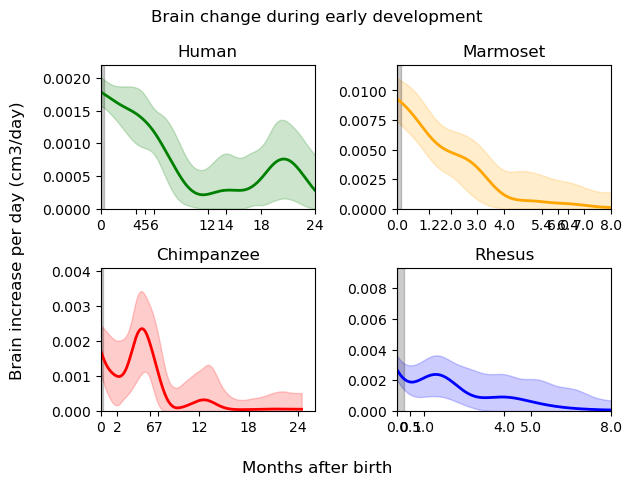

In [ ]:
i = 0
derivative_fit = []
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        derivatives_dataset_species = df_fit[(df_fit.species == species)]
        df_event_specie = df_events[df_events.species == species]
        gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
        gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
        late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

        x = derivatives_dataset_species["x_dydx"].values[0]
        all_devs = derivatives_dataset_species["derivatives"].values[0]
        
        average_derivative = gaussian_filter1d(np.mean(np.array(all_devs), axis=0), sigma = 10)/adult_size[species]
        low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 10)/adult_size[species]
        high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 10)/adult_size[species]

        y = average_derivative

        col.plot(x/DIVISION_DAYS - gestation_days/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
        col.fill_between(x/DIVISION_DAYS - gestation_days/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

        col.axvline(x = 0 , color = "black",linestyle = '-')
        col.axvspan(0 - gestation_days_sd/DIVISION_DAYS, 0 + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color='black')
        

        col.set_title(species)
        col.set_ylim(bottom=0)
        col.set_xlim(left=0)

        # Set x-axis ticks every 6 months
        max_months = (x.max() / DIVISION_DAYS) - (gestation_days / DIVISION_DAYS)
        if species == "Human":
            ticks = np.arange(0, 24 + 1, 6).tolist()
            col.set_xlim(right=24)
            if 5 not in ticks:
                ticks.append(4) #synaptic peak
                ticks.append(5)  # Add month 5 if not already included
                ticks.append(14)  # which is remarkably in line with the peaking age of human cortical thickness at around 14 mo of age (29) F. Wang et al., Developmental topography of cortical thickness during infancy. Proc. Natl. Acad. Sci. U.S.A. 116, 15855–15860 (2019).
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
        elif species == "Marmoset":
            ticks = np.arange(0, max_months + 1, 2).tolist()
            ticks.append(3)
            ticks.append(7)
            ticks.append(6.4) #auditory peak
            ticks.append(5.4) 
            ticks.append(1.2) 
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
            col.set_xlim(right=8)
        elif species == "Rhesus":
            ticks = np.arange(0, 8 + 1, 4).tolist()
            ticks.append(5) #peak of cortical tickness https://www.pnas.org/doi/10.1073/pnas.2303313120#sec-3
            ticks.append(0.5) #peak of cortical tickness https://www.pnas.org/doi/10.1073/pnas.2303313120#sec-3
            ticks.append(1) #peak of cortical tickness https://www.pnas.org/doi/10.1073/pnas.2303313120#sec-3
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
            col.set_xlim(right=8)
        elif species == "Chimpanzee":
            ticks = np.arange(0, max_months + 1, 6).tolist()
            ticks.append(2) #https://onlinelibrary-wiley-com.ezproxy.princeton.edu/doi/10.1111/j.1467-7687.2011.01069.x
            ticks.append(7) #https://onlinelibrary-wiley-com.ezproxy.princeton.edu/doi/10.1111/j.1467-7687.2011.01069.x
            ticks = sorted(ticks)  # Ensure the ticks are sorted
            col.set_xticks(ticks)
        #The grunting rates in this context increase over the following months with a peak around the seventh month, coinciding with Goodall’s (1986) observation of the onset of greeting grunts.
        #Bründl et al., 2021
        i += 1

fig.supxlabel("Months after birth") 
fig.supylabel('Brain increase per day (cm3/day)')
fig.suptitle("Brain change during early development")
fig.tight_layout()
fig.savefig("{0}/figs/2B_absolute_bootstraping_Months_after_birth.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

 For example, cluster 2 contains most parts of the primary cortices (the primary motor cortex and primary somatosensory area) which may reflect the development speed of the motor and sensory functions of macaque monkeys.  https://www.pnas.org/doi/10.1073/pnas.2303313120#sec-3


I have this description of the rhesus brain:

The clusters approximately encompass 1) the orbitofrontal, inferior temporal, precuneus, and most of the occipital cortices, and postcentral gyrus (pink color); 2) the superior temporal sulcus, cingulate cortex, precentral gyrus, and calcarine sulcus (yellow color); 3) the dorsal prefrontal, posterior superior temporal, and supramarginal gyrus (blue color); and 4) the insula and medial temporal cortices (green color).

I want to know where the areas related to vocal learning (ACC, Auditory cortex, A4, A6, A45, A46, A47) would be in these clusters


O ChatGPT disse:
Raciocinado sobre áreas cerebrais no rhesus por 14 segundos
Based on the anatomical regions each cluster covers, here is where those vocal‐learning‐related areas most likely fall:

Anterior Cingulate Cortex (ACC):
Included in Cluster 2 (which encompasses the cingulate cortex).

Primary/Secondary Auditory Cortex:
Also most likely in Cluster 2 (which includes the superior temporal sulcus and surrounding temporal areas).

Area 4 (A4, primary motor cortex) and Area 6 (A6, premotor cortex):
Both are located around the precentral gyrus, so they would fall under Cluster 2 as well.

Area 45 and Area 47:
These areas lie in the ventrolateral/orbitofrontal portions of the prefrontal cortex. Since Cluster 1 includes the orbitofrontal region, Areas 45 and 47 would most closely align with Cluster 1.

Area 46 (A46):
This corresponds to dorsolateral prefrontal cortex, which is included in Cluster 3 (described as “dorsal prefrontal”).

Prolonged Synaptogenesis. Like humans (11, 12), chimpanzees exhibit a substantially later peak in synapse density (between 3 and 5 y) than macaques (3 mo) (9), and a prolonged phase of synapse pruning, which extends into the late juvenile period (around 10 y). Evidence for an extended period of synaptic ref inement in chimpanzees is consistent with previous findings indicating that prefrontal white matter development is prolonged until at least the mid-juvenile period in this species (28). This f inding contrasts, however, with a recent report by Liu et al. (10), suggesting that relatively increased synapse-associated gene expression in the prefrontal cortex continues until 5 y of age in humans only, but in chimpanzees and macaques synaptic gene expression peaks within the first year of life. Because the analysis of Liu et al. (10) included only three chimpanzee brains between 1 y of age and adulthood, however, differences in the sample sizes represented in these two studies could contribute to the divergent findings, especially because interindividual variation is pronounced. Additionally, little is still known regarding how gene expression regulates anatomical changes in synapse densities during development (36). Prolonged synaptogenesis in chimpanzees is consistent with behavioral evidence indicating that the juvenile period is critical for social learning of group-specific behaviors acquired from conspecifics. Tool use in chimpanzees displays regional variation to an extent that exceeds other nonhuman animals, including such varied techniques as stone hammering to access nuts, dipping or digging for ants or termites with sticks, and stabbing small vertebrates with spears (37). Young chimpanzees require at least 5 y of postnatal development before they are able to master tool use, and the acquisition of competence in these skills.
https://www.pnas.org/doi/abs/10.1073/pnas.1301224110




Chimpanzee
Rhesus
Human
Marmoset


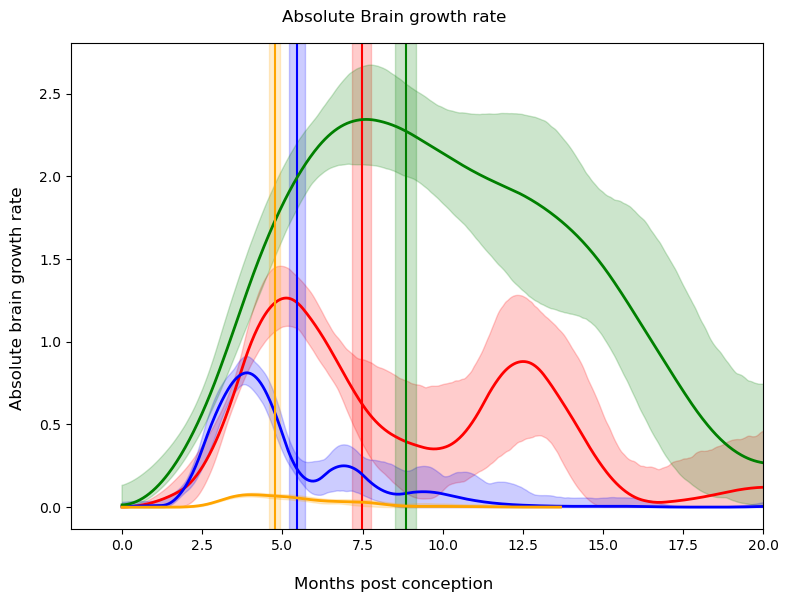

In [ ]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(figsize=(8, 6))

for species in ["Chimpanzee","Rhesus","Human","Marmoset"]:
    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    df_event_specie = df_events[df_events.species == species]
    gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
    gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
    late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

    x = derivatives_dataset_species["x_dydx"].values[0]
    all_devs = derivatives_dataset_species["derivatives"].values[0]
    
    average_derivative = np.mean(np.array(all_devs), axis=0)
    low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
    high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

    y = average_derivative

    ax.axvline(x = gestation_days/DIVISION_DAYS, color = species_color[species],linestyle = '-')
    ax.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color=species_color[species])

    ax.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
    ax.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

    ax.set_xlim(right=20)

fig.supxlabel(X_LABEL) 
fig.supylabel('Absolute brain growth rate')
fig.suptitle("Absolute Brain growth rate")
fig.tight_layout()
fig.savefig("{0}/figs/2B_absolute_bootstraping_PLOTTING_TOGETHER.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

Chimpanzee
Rhesus
Human
Marmoset


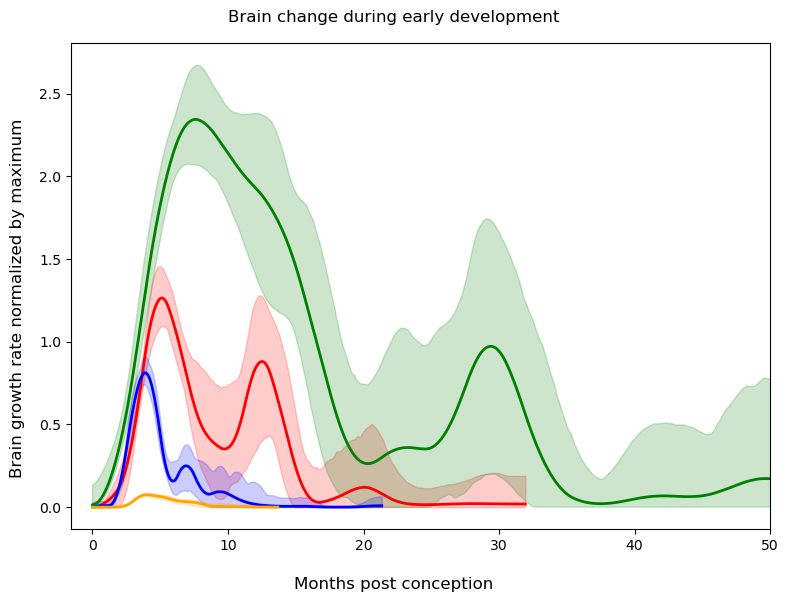

In [ ]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(figsize=(8, 6))

for species in ["Chimpanzee","Rhesus","Human","Marmoset"]:
    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    df_event_specie = df_events[df_events.species == species]
    gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
    gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
    late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

    x = derivatives_dataset_species["x_dydx"].values[0]
    all_devs = derivatives_dataset_species["derivatives"].values[0]
    
    average_derivative = np.mean(np.array(all_devs), axis=0)
    low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
    high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

    y = average_derivative

    #ax.axvline(x = gestation_days/DIVISION_DAYS, color = species_color[species],linestyle = '-')
    #ax.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color=species_color[species])

    ax.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
    ax.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

    ax.set_xlim(right=50)

fig.supxlabel(X_LABEL) 
fig.supylabel('Brain growth rate normalized by maximum')
fig.suptitle("Brain change during early development")
fig.tight_layout()
fig.savefig("{0}/figs/2B_absolute_bootstraping_PLOTTING_TOGETHER_NOBIRTH.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

Chimpanzee
Rhesus
Human
Marmoset


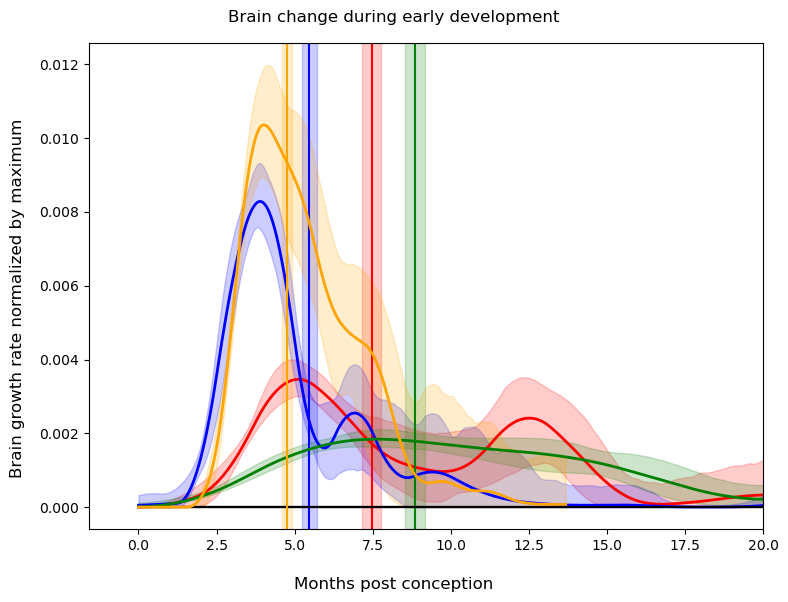

In [ ]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(figsize=(8, 6))

for species in ["Chimpanzee","Rhesus","Human","Marmoset"]:

    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    df_event_specie = df_events[df_events.species == species]
    gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
    gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
    late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

    x = derivatives_dataset_species["x_dydx"].values[0]
    all_devs = derivatives_dataset_species["derivatives"].values[0]
    
    average_derivative = np.mean(np.array(all_devs), axis=0)
    low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
    high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

    y = average_derivative

    y = y/adult_size[species]
    low_percentil = low_percentil/adult_size[species]
    high_percentil = high_percentil/adult_size[species]

    ax.hlines(0,0,20, color = "black",linestyle = '-')
    ax.axvline(x = gestation_days/DIVISION_DAYS, color = species_color[species],linestyle = '-')
    ax.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color=species_color[species])
        
    ax.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
    ax.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

    ax.set_xlim(right=20)


fig.supxlabel(X_LABEL) 
fig.supylabel('Brain growth rate normalized by maximum')
fig.suptitle("Brain change during early development")
fig.tight_layout()
fig.savefig("{0}/figs/2B_normalized_adult_brain_bootstraping_PLOTTING_TOGETHER_birth.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

Chimpanzee
Rhesus
Human
Marmoset


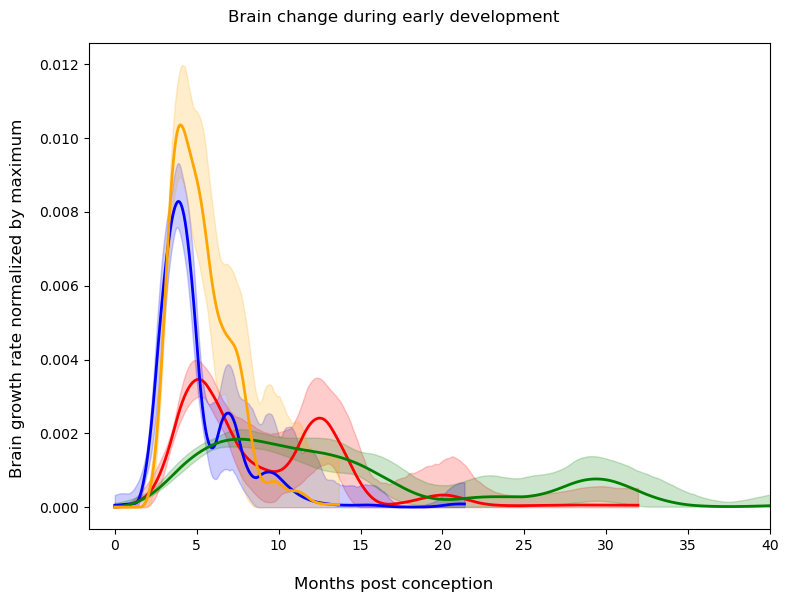

In [ ]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(figsize=(8, 6))

for species in ["Chimpanzee","Rhesus","Human","Marmoset"]:

    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    df_event_specie = df_events[df_events.species == species]
    gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
    gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
    late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

    x = derivatives_dataset_species["x_dydx"].values[0]
    all_devs = derivatives_dataset_species["derivatives"].values[0]
    
    average_derivative = np.mean(np.array(all_devs), axis=0)
    low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
    high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

    y = average_derivative

    y = y/adult_size[species]
    low_percentil = low_percentil/adult_size[species]
    high_percentil = high_percentil/adult_size[species]


    #ax.axvline(x = gestation_days/DIVISION_DAYS, color = species_color[species],linestyle = '-')
    #ax.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color=species_color[species])
        
    ax.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
    ax.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

    ax.set_xlim(right=40)


fig.supxlabel(X_LABEL) 
fig.supylabel('Brain growth rate normalized by maximum')
fig.suptitle("Brain change during early development")
fig.tight_layout()
fig.savefig("{0}/figs/2B_normalized_adult_brain_bootstraping_PLOTTING_TOGETHER_NObirth.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

Human
Marmoset
Chimpanzee
Rhesus


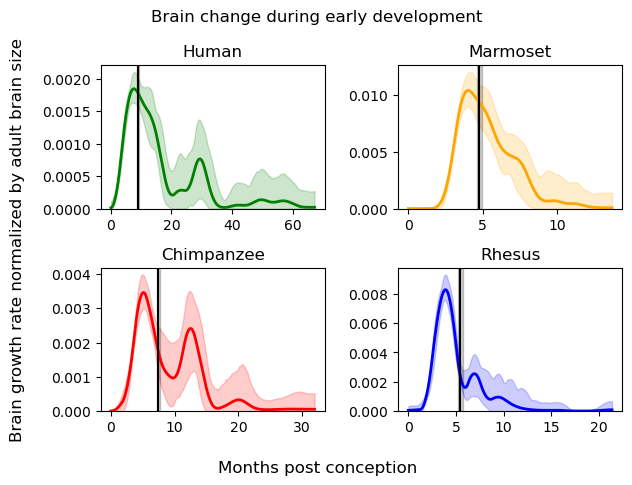

In [ ]:
i = 0

derivative_fit = []
fig, ax = plt.subplots(nrows=2, ncols=2)

for row in ax:
    for col in row:
        species = species_list[i]
        print(species)
        derivatives_dataset_species = df_fit[(df_fit.species == species)]
        df_event_specie = df_events[df_events.species == species]
        gestation_days = df_event_specie[df_event_specie.event == "gestation"]["avg_wkspc"].values[0]*7
        gestation_days_sd = df_event_specie[df_event_specie.event == "gestation"]["sd_(days)"].values[0]
        late_infancy_ends = df_event_specie[(df_event_specie.event == "dental_late_infancy_ends")]["avg_wkspc"].values[0]*7

        x = derivatives_dataset_species["x_dydx"].values[0]
        all_devs = derivatives_dataset_species["derivatives"].values[0]
        
        average_derivative = np.mean(np.array(all_devs), axis=0)
        low_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 2.5, axis=0), sigma = 1)
        high_percentil = gaussian_filter1d(np.percentile(np.array(all_devs),q = 97.5, axis=0), sigma = 1)

        y = average_derivative

        y = y/adult_size[species]
        low_percentil = low_percentil/adult_size[species]
        high_percentil = high_percentil/adult_size[species]


        col.plot(x/DIVISION_DAYS,y, '-', color = species_color[species],linewidth = 2)
        col.fill_between(x/DIVISION_DAYS, low_percentil, high_percentil, color=species_color[species], alpha=0.2)

        col.axvline(x = gestation_days/DIVISION_DAYS, color = "black",linestyle = '-')
        col.axvspan(gestation_days/DIVISION_DAYS - gestation_days_sd/DIVISION_DAYS, gestation_days/DIVISION_DAYS + gestation_days_sd/DIVISION_DAYS, alpha=0.2, color='black')
        

        xlim = late_infancy_ends
        #col.set_xlim(0,xlim)
        col.set_title(species)
        col.set_ylim(bottom=0)
        i += 1

fig.supxlabel(X_LABEL) 
fig.supylabel('Brain growth rate normalized by adult brain size')
fig.suptitle("Brain change during early development")
fig.tight_layout()
fig.savefig("{0}/figs/2B_normalized_brain_bootstraping.pdf".format(PYTHON_PATH),dpi = 800)
plt.show()

In [ ]:
df_fit

,species,x_dydx,derivatives,derivatives_max,derivatives_peak_at_birth
0,Human,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[3.064614918457664e-05, 0.0001225853041546543...","[2.4194334486632556, 2.3492183323747895, 2.680...","[[0.06434829108500505, 0.06608864961643122, 0...."
1,Marmoset,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[-3.461231301571388e-12, -3.5487168759118504e...","[0.07450135434353378, 0.07858159977567802, 0.0...","[[0.016807876924726305, 0.019268520623952585, ..."
2,Chimpanzee,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[9.404629309983648e-06, 3.761861931650401e-05...","[1.1478227360204727, 1.1026191926860491, 1.191...","[[0.19500279676998464, 0.19793996032802777, 0...."
3,Rhesus,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ...","[[0.0023179056404032394, 0.002373807627403579,...","[0.7734570127717522, 0.7663530654780821, 0.758...","[[0.5695318153447586, 0.5868433007572216, 0.60..."


In [ ]:
distances_from_peak_plot = {"species":[],
                            "close_to_peak_norm":[],
                            "distance_from_peak_norm":[],
                            "distance_from_peak_abs":[]}

for species in species_list:
    print(species)
    derivatives_dataset_species = df_fit[(df_fit.species == species)]
    derivatives_peak_at_birth = derivatives_dataset_species["derivatives_peak_at_birth"].values[0]
    derivatives_max = derivatives_dataset_species["derivatives_max"].values[0]

    all_distance_from_peak_norm = []
    all_distance_from_peak_abs = []
    all_close_to_peak_norm = []
    for index, dist_peak_distances in enumerate(derivatives_peak_at_birth):
        all_distance_from_peak_norm.extend(np.array(dist_peak_distances))
        all_close_to_peak_norm.extend(1-np.array(dist_peak_distances))
        all_distance_from_peak_abs.extend(np.array(dist_peak_distances)*derivatives_max[index])

    
    distances_from_peak_plot["species"].extend([species]*len(all_distance_from_peak_norm))
    distances_from_peak_plot["distance_from_peak_norm"].extend(all_distance_from_peak_norm)
    distances_from_peak_plot["close_to_peak_norm"].extend(all_close_to_peak_norm)
    distances_from_peak_plot["distance_from_peak_abs"].extend(all_distance_from_peak_abs)
    
distances_from_peak_plot = pd.DataFrame(distances_from_peak_plot)
  

SPECIES = ["Human", "Marmoset","Chimpanzee", "Rhesus"]
COLORS = ["#1A936F","#FFB400","#FF5A5F", "#007A87",]
SHIFT = 0.05
POSITIONS = [0 + SHIFT, 1 + SHIFT, 2 + SHIFT, 3+ SHIFT]
# The style of the line that represents the median.
medianprops = {"linewidth": 1.5, "color": "#a9a9a9", "solid_capstyle": "butt"}
# The style of the box ... This is also used for the whiskers
boxprops = {"linewidth": 1.5, "color": "#a9a9a9"}


Human
Marmoset
Chimpanzee
Rhesus


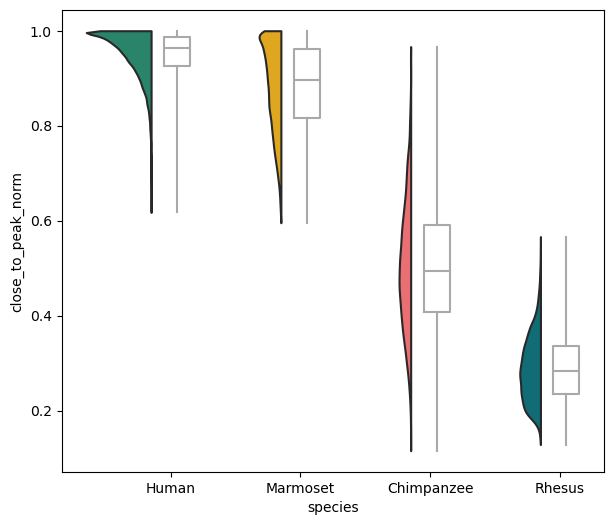

In [ ]:
PLOT_VARIABLE = "close_to_peak_norm"
fig, ax = plt.subplots(figsize=(7, 6))
pt.half_violinplot(
    y=PLOT_VARIABLE, x="species", palette=COLORS, 
    inner=None, data=distances_from_peak_plot, width=1, ax=ax,cut=0)

boxplot_data = [
    distances_from_peak_plot[distances_from_peak_plot["species"] == species][PLOT_VARIABLE].values 
    for species in SPECIES]

ax.boxplot(boxplot_data, 
    vert=True, positions=POSITIONS, manage_ticks=False, showfliers = False, showcaps = False,  
    medianprops = medianprops, whiskerprops = boxprops,boxprops = boxprops, widths=0.2,whis=[0, 100])

plt.savefig("{0}/figs/2C_bootstrap_norm_max_clouds.svg".format(PYTHON_PATH),dpi = 200)


# percentil bonds of the distributions

In [ ]:
percentil = 0.95

for species in species_list:
    lower_percentile = (1 - percentil) / 2
    upper_percentile = 1 - lower_percentile
    data = distances_from_peak_plot[distances_from_peak_plot.species == species]["close_to_peak_norm"]
    percentil_interval = np.percentile(data, [100 * lower_percentile, 100 * upper_percentile])

    mean = np.mean(data)
    median = np.median(data)
    std = np.std(data)


    print(species)
    print(f"Mean: {round(mean,2)}, Median: {round(median,2)}, Std: {round(std,2)}")
    print(f"95% Percentil bounds: {percentil_interval}")
    print()

Human
Mean: 0.95, Median: 0.96, Std: 0.05
95% Percentil bounds: [0.82505182 0.99981418]

Marmoset
Mean: 0.88, Median: 0.9, Std: 0.09
95% Percentil bounds: [0.68580974 0.99931904]

Chimpanzee
Mean: 0.5, Median: 0.49, Std: 0.13
95% Percentil bounds: [0.26775245 0.77125719]

Rhesus
Mean: 0.29, Median: 0.28, Std: 0.07
95% Percentil bounds: [0.17942941 0.43226978]



## ROC curve

<Axes: xlabel='close_to_peak_norm', ylabel='Count'>

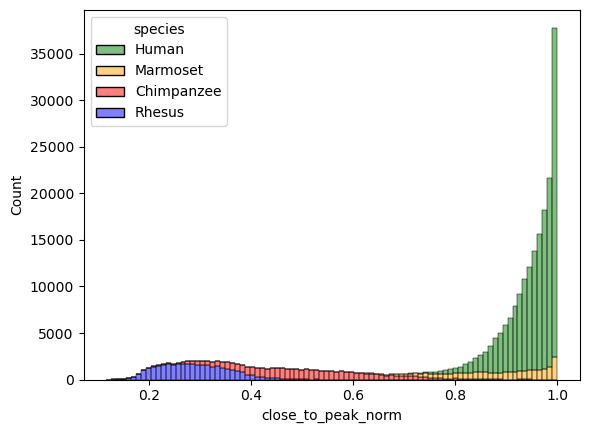

In [ ]:
sns.histplot(hue="species", x="close_to_peak_norm", data=distances_from_peak_plot,multiple="stack", alpha = 0.5,
            palette=["green","orange","red","blue"])

In [ ]:
df_all_box = pd.DataFrame(distances_from_peak_plot)
df_all_box.head()

,species,close_to_peak_norm,distance_from_peak_norm,distance_from_peak_abs
0,Human,0.935652,0.064348,0.155686
1,Human,0.933911,0.066089,0.159897
2,Human,0.932194,0.067806,0.164053
3,Human,0.930499,0.069501,0.168154
4,Human,0.928826,0.071174,0.172200


In [ ]:
from sklearn.metrics import auc

#ROC calculation
def calculating_roc(altricial_species,precocial_species,confusion_matrix,pair,step=0.01):


    for threshold in np.arange(0, 1 + step, step):
        confusion_matrix["threshold"].append(threshold) #if value >= threshold --> it is altricial (True)
        confusion_matrix["pair_comparison"].append("{0}_{1}".format(pair[0],pair[1]))

        tp = len(altricial_species[altricial_species.close_to_peak_norm >= threshold])
        confusion_matrix["actually_altricial_predicted_altricial"].append(tp)

        fp = len(precocial_species[precocial_species.close_to_peak_norm >= threshold])
        confusion_matrix["actually_precocial_predicted_altricial"].append(fp)

        fn = len(altricial_species[altricial_species.close_to_peak_norm < threshold])
        confusion_matrix["actually_altricial_predicted_precocial"].append(fn)

        tn = len(precocial_species[precocial_species.close_to_peak_norm < threshold])
        confusion_matrix["actually_precocial_predicted_precocial"].append(tn)

        try:
            confusion_matrix["TPR"].append(tp/(tp + fn))
        except:
            confusion_matrix["TPR"].append(0)
        try:
            confusion_matrix["FPR"].append(fp/(tn + fp))
        except:
            confusion_matrix["FPR"].append(0)

    return confusion_matrix

confusion_matrix_ref = {"actually_altricial_predicted_altricial":[],"actually_precocial_predicted_altricial":[],
                            "actually_altricial_predicted_precocial":[],"actually_precocial_predicted_precocial":[],
                            "pair_comparison":[],"threshold":[],
                            "TPR":[], #true positive rate/recall/sensitivity or true positive/ all positive ("altricials I got right/all altricials")
                            "FPR":[], #false positive rate/ false alarm rate or false positive/ all negative ("precocials I classified as altricial/ all precocials")
                            }

list_of_pairs = [["Marmoset","Rhesus"],["Marmoset","Chimpanzee"],["Human","Rhesus"],["Human","Chimpanzee"],
                ["Human","Marmoset"],["Chimpanzee","Rhesus"]]


confusion_matrix = copy.deepcopy(confusion_matrix_ref)

for pair in list_of_pairs:
    print(pair)
    altricial_species = df_all_box[df_all_box.species == pair[0]]
    precocial_species = df_all_box[df_all_box.species == pair[1]]
    confusion_matrix = calculating_roc(altricial_species,precocial_species,confusion_matrix,pair,0.05)
    
confusion_matrix = pd.DataFrame(confusion_matrix)

['Marmoset', 'Rhesus']
['Marmoset', 'Chimpanzee']
['Human', 'Rhesus']
['Human', 'Chimpanzee']
['Human', 'Marmoset']
['Chimpanzee', 'Rhesus']


Marmoset_Rhesus
Marmoset_Chimpanzee
Human_Rhesus
Human_Chimpanzee
Human_Marmoset
Chimpanzee_Rhesus


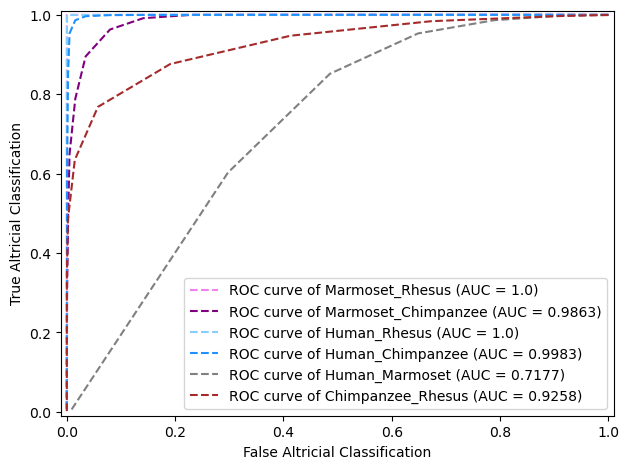

In [ ]:
colors = ["violet","purple","lightskyblue","dodgerblue","grey","brown"]

auc_value = 0
for i, pair in enumerate(confusion_matrix["pair_comparison"].unique()):
    print(pair)
    conf_matrix_pair = confusion_matrix[confusion_matrix.pair_comparison == pair]
    fpr = list(conf_matrix_pair["FPR"])
    tpr = list(conf_matrix_pair["TPR"])
    auc_value = auc(fpr,tpr)
    plt.plot(fpr, tpr,"--",color = colors[i],label='ROC curve of {0} (AUC = {1})'.format(pair,np.round(auc_value,4)))

plt.xlim(-0.01,1.01)
plt.ylim(-0.01,1.01)
plt.legend()
plt.xlabel("False Altricial Classification")
plt.ylabel("True Altricial Classification")
plt.tight_layout()
plt.savefig("{0}/figs/ROC_plot_bootstrap.pdf".format(PYTHON_PATH),dpi = 300)


In [ ]:
#Creating a bootstrap for the AUC of each species:
CALC_BOOTSTRAP = False

auc_bootstrap = {"pair":[],"auc_mean":[],"auc_std":[],
                    "auc_2.5":[],"auc_97.5":[]}
if CALC_BOOTSTRAP:
    N_iterations = 1000
    for pair in list_of_pairs:
        print(pair)
        altricial_species = df_all_box[df_all_box.species == pair[0]]
        precocial_species = df_all_box[df_all_box.species == pair[1]]
        aucs = []
        for i in range(N_iterations):
            confusion_matrix_pair = pd.DataFrame(calculating_roc(altricial_species.sample(frac=1, replace=True),precocial_species.sample(frac=1, replace=True),
                                                    copy.deepcopy(confusion_matrix_ref),pair,0.05))
            fpr = list(confusion_matrix_pair["FPR"])
            tpr = list(confusion_matrix_pair["TPR"])
            aucs.append(auc(fpr,tpr))
            if i%100 == 0:
                print(i)
        auc_bootstrap["pair"].append(pair)
        auc_bootstrap["auc_mean"].append(np.mean(aucs))
        auc_bootstrap["auc_std"].append(np.std(aucs))
        auc_bootstrap["auc_2.5"].append(np.percentile(aucs,2.5))
        auc_bootstrap["auc_97.5"].append(np.percentile(aucs,97.5))

auc_bootstrap = pd.DataFrame(auc_bootstrap)

In [ ]:
auc_bootstrap


,pair,auc_mean,auc_std,auc_2.5,auc_97.5


In [ ]:
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu


for pair in list_of_pairs:
    print(pair)
    altricial_species = df_all_box[df_all_box.species == pair[0]]
    precocial_species = df_all_box[df_all_box.species == pair[1]]
    
# Compute AUC for both models
auc_model_1 = roc_auc_score(y_true, model_1_pred_proba)
auc_model_2 = roc_auc_score(y_true, model_2_pred_proba)

# Perform Mann-Whitney U test to compare AUCs
stat, p_value = mannwhitneyu(model_1_pred_proba, model_2_pred_proba, alternative='two-sided')

print(f"AUC for Model 1: {auc_model_1}, AUC for Model 2: {auc_model_2}")
print(f"Mann-Whitney U Test statistic: {stat}, p-value: {p_value}")

['Marmoset', 'Rhesus']
['Marmoset', 'Chimpanzee']
['Human', 'Rhesus']
['Human', 'Chimpanzee']
['Human', 'Marmoset']
['Chimpanzee', 'Rhesus']


NameError: name 'y_true' is not defined

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu, ttest_ind

# Assume list_of_pairs is defined, e.g.:
# list_of_pairs = [("Chimpanzee", "Rhesus"), ("Human", "Marmoset")]

# Use the raw distribution column you want to compare.
col_to_compare = "possible_values_normalized_by_max"

for pair in list_of_pairs:
    print("Comparing species:", pair)
    # Select the data for each species.
    group1 = df_all_box[df_all_box['species'] == pair[0]][col_to_compare].values
    group2 = df_all_box[df_all_box['species'] == pair[1]][col_to_compare].values

    # Perform a non-parametric Mann–Whitney U test.
    stat_mw, p_mw = mannwhitneyu(group1, group2, alternative='two-sided')
    # Optionally, perform an independent t-test
    stat_ttest, p_ttest = ttest_ind(group1, group2, equal_var=False)

    print(f"Mann-Whitney U Test: Statistic = {stat_mw}, p-value = {p_mw:.3g}")
    print(f"Independent t-test: Statistic = {stat_ttest}, p-value = {p_ttest:.3g}\n")

Comparing species: ['Marmoset', 'Rhesus']
Mann-Whitney U Test: Statistic = 3272335990.0, p-value = 0
Independent t-test: Statistic = 1168.3533486716478, p-value = 0

Comparing species: ['Marmoset', 'Chimpanzee']
Mann-Whitney U Test: Statistic = 3302291941.0, p-value = 0
Independent t-test: Statistic = 695.6001836891304, p-value = 0

Comparing species: ['Human', 'Rhesus']
Mann-Whitney U Test: Statistic = 6298955292.0, p-value = 0
Independent t-test: Statistic = 1695.3891395454873, p-value = 0

Comparing species: ['Human', 'Chimpanzee']
Mann-Whitney U Test: Statistic = 6357760416.0, p-value = 0
Independent t-test: Statistic = 1062.4180146528763, p-value = 0

Comparing species: ['Human', 'Marmoset']
Mann-Whitney U Test: Statistic = 4345888791.0, p-value = 0
Independent t-test: Statistic = 379.9603241856594, p-value = 0

Comparing species: ['Chimpanzee', 'Rhesus']
Mann-Whitney U Test: Statistic = 4013865195.0, p-value = 0
Independent t-test: Statistic = 317.62082650075246, p-value = 0



In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score
from scipy.stats import mannwhitneyu

# Assume list_of_pairs is defined, for example:
# list_of_pairs = [("Chimpanzee", "Rhesus"), ("Human", "Marmoset")]

col_to_compare = "possible_values_normalized_by_max"

for pair in list_of_pairs:
    print("Comparing species:", pair)
    # Extract the data for each species
    group1 = df_all_box[df_all_box['species'] == pair[0]][col_to_compare].values
    group2 = df_all_box[df_all_box['species'] == pair[1]][col_to_compare].values

    # Create true binary labels: 1 for species in pair[0], 0 for species in pair[1].
    y_true = np.concatenate([np.ones(len(group1)), np.zeros(len(group2))])
    # Use the column values as the prediction score.
    scores = np.concatenate([group1, group2])
    
    # Calculate ROC AUC.
    auc = roc_auc_score(y_true, scores)
    
    # Optionally, perform a Mann-Whitney U test as well.
    stat_mw, p_mw = mannwhitneyu(group1, group2, alternative='two-sided')
    
    print(f"ROC AUC: {auc:.3f}")
    print(f"Mann-Whitney U Test: Statistic = {stat_mw}, p-value = {p_mw:.3g}\n")

Comparing species: ['Marmoset', 'Rhesus']
ROC AUC: 1.000
Mann-Whitney U Test: Statistic = 3272335990.0, p-value = 0

Comparing species: ['Marmoset', 'Chimpanzee']
ROC AUC: 1.000
Mann-Whitney U Test: Statistic = 3302291941.0, p-value = 0

Comparing species: ['Human', 'Rhesus']
ROC AUC: 1.000
Mann-Whitney U Test: Statistic = 6298955292.0, p-value = 0

Comparing species: ['Human', 'Chimpanzee']
ROC AUC: 1.000
Mann-Whitney U Test: Statistic = 6357760416.0, p-value = 0

Comparing species: ['Human', 'Marmoset']
ROC AUC: 0.936
Mann-Whitney U Test: Statistic = 4345888791.0, p-value = 0

Comparing species: ['Chimpanzee', 'Rhesus']
ROC AUC: 0.896
Mann-Whitney U Test: Statistic = 4013865195.0, p-value = 0

